Data Exploration

In [72]:
import pandas as pd
calories_df = pd.read_csv("/Users/naomigong/Coding/ML_Projects/calories_burnt/calories.csv")
data_df = pd.read_csv("/Users/naomigong/Coding/ML_Projects/calories_burnt/exercise.csv")

calories_df = pd.merge(data_df, calories_df, on="User_ID", how ="left")

In [73]:
#finding null values
calories_df.isna().sum()  

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [74]:
from sklearn.preprocessing import LabelBinarizer
gender_labeler = LabelBinarizer()
calories_df["Gender"] = gender_labeler.fit_transform(calories_df["Gender"])


Text(0.5, 1.0, 'Weight vs Calories')

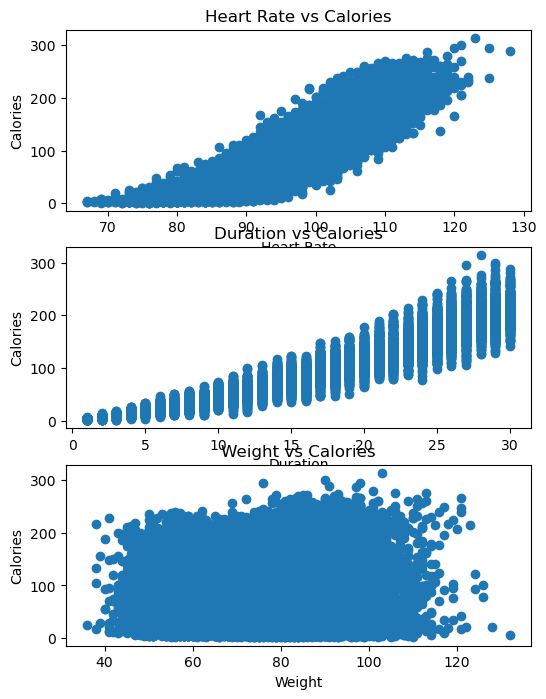

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, ncols=1, figsize=(6, 8))
ax1.scatter(calories_df["Heart_Rate"], calories_df["Calories"])
ax1.set_xlabel("Heart Rate")
ax1.set_ylabel("Calories")
ax1.set_title("Heart Rate vs Calories")

ax2.scatter(calories_df["Duration"], calories_df["Calories"])
ax2.set_xlabel("Duration")
ax2.set_ylabel("Calories")
ax2.set_title("Duration vs Calories")

ax3.scatter(calories_df["Weight"], calories_df["Calories"])
ax3.set_xlabel("Weight")
ax3.set_ylabel("Calories")
ax3.set_title("Weight vs Calories")

<Axes: >

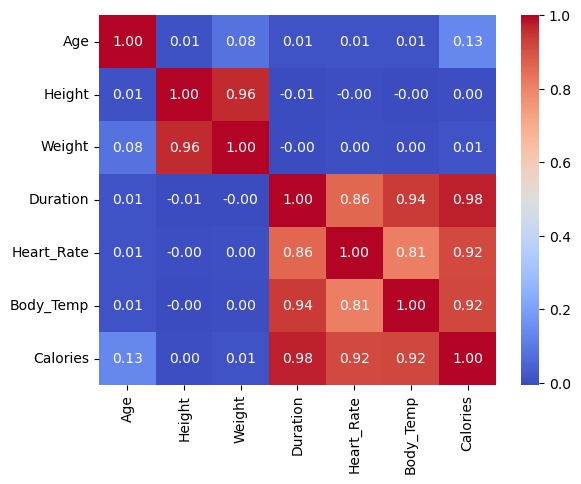

In [76]:

columns_of_interest = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "Calories"]
correlation_matrix = calories_df[columns_of_interest].corr(method = "spearman")
sns.heatmap(correlation_matrix, annot = True, fmt = ".2f", cmap = "coolwarm")

From the heat map: body temperature, heart-rate, duration have the most correlation with calories burnt

In [77]:
features = calories_df[["Heart_Rate", "Body_Temp", "Duration"]]
target = calories_df["Calories"]

Imports + Split Data

In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size=0.2, random_state=43)

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

Model Training -- Using Linear Regression

In [92]:
from sklearn.linear_model import LinearRegression
def lin_reg_model(X_train, X_test, Y_train, Y_test):
    linreg = LinearRegression()
    #fit the model to the data
    linreg.fit(X_train, Y_train)
    y_pred_train = linreg.predict(X_train)
    #check the accuracy of the training data
    train_r2 = r2_score(Y_train, y_pred_train)
    y_pred_test = linreg.predict(X_test)
    test_r2 = r2_score(Y_test, y_pred_test)

    print(f"The training r2 score is {train_r2}")
    print(f"The testing r2 score is {test_r2}")

    #checking mean squared error
    mse_train = mean_squared_error(Y_train, y_pred_train)
    mse_test = mean_squared_error(Y_test, y_pred_test)
    print(f"The training mse score is {mse_train}")
    print(f"The testing mse score is {mse_test}")

    #Using Cross validation scores
    scores = cross_val_score(linreg, features, target, cv = 5)
    for index, score in enumerate(scores):
        print(f"The {index}th r2 score is {score}")
    print(f"the average r2 score is {sum(scores)/len(scores)}")
    return linreg
    

In [96]:
linear_final_model = lin_reg_model(X_train, X_test, Y_train, Y_test)

The training r2 score is 0.9462757411398546
The testing r2 score is 0.9461508231904987
The training mse score is 210.51534623955948
The testing mse score is 206.18049644071687
The 0th r2 score is 0.9469055553967997
The 1th r2 score is 0.9442069163003123
The 2th r2 score is 0.9474384438653206
The 3th r2 score is 0.9486037675335974
The 4th r2 score is 0.9437698519058563
the average r2 score is 0.9461849070003773


Model Training -- With Random Forest

In [86]:
from sklearn.ensemble import RandomForestRegressor
randomforest = RandomForestRegressor()
randomforest.fit(X_train, Y_train)
y_preds_train = randomforest.predict(X_train)
y_preds_test = randomforest.predict(X_test)

#checking the accuracy of model using MSE and R2
train_r2_rf = r2_score(Y_train, y_preds_train)
test_r2_rf = r2_score(Y_test, y_preds_test)

print(f"The training r2 score is {train_r2_rf}")
print(f"The testing r2 score is {test_r2_rf}")

#Using Cross validation scores
scores = cross_val_score(randomforest, features, target, cv = 5)
for index, score in enumerate(scores):
    print(f"The {index}th r2 score is {score}")
print(f"the average r2 score is {sum(scores)/len(scores)}")

The training r2 score is 0.975474718723615
The testing r2 score is 0.9509600098067208
The 0th r2 score is 0.9506989817385313
The 1th r2 score is 0.950281205600817
The 2th r2 score is 0.9539693458116352
The 3th r2 score is 0.953407875938643
The 4th r2 score is 0.9514557469667198
the average r2 score is 0.9519626312112692


Using Standardization to improve model


In [ ]:
# from sklearn.preprocessing import StandardScaler
# standardizer = StandardScaler()
# X_train_standard = standardizer.fit_transform(X_train) #finds the mean and standard deviation and applies it
# X_test_standard = standardizer.transform(X_test) #applies the mean and standard deviation of the training set to testing
# linreg = LinearRegression()
# #fit the model to the data
# linreg.fit(X_train_standard, Y_train)
# y_pred_train = linreg.predict(X_train_standard)
#  #check the accuracy of the training data
# train_r2 = r2_score(Y_train, y_pred_train)
# y_pred_test = linreg.predict(X_test_standard)
# test_r2 = r2_score(Y_test, y_pred_test)

# print(f"The training r2 score is {train_r2}")
# print(f"The testing r2 score is {test_r2}")


# #Using Cross validation scores
# scores = cross_val_score(linreg, features, target, cv = 5)
# for index, score in enumerate(scores):
#     print(f"The {index}th r2 score is {score}")
# print(f"the average r2 score is {sum(scores)/len(scores)}")

The training r2 score is 0.9462757411398546
The testing r2 score is 0.9461508231904986
The 0th r2 score is 0.9469055553967997
The 1th r2 score is 0.9442069163003123
The 2th r2 score is 0.9474384438653206
The 3th r2 score is 0.9486037675335974
The 4th r2 score is 0.9437698519058563
the average r2 score is 0.9461849070003773


Testing on a new data point

In [97]:
test_point =[[130, 41, 60]]
print(linear_final_model.predict(test_point))

[437.91799486]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
